In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras

In [2]:
file = open("train_data.txt")
data = file.readlines()
file.close()
print(data)

['The cat sat on the mat.\n', 'The dog jumped over the fence.\n', 'I love reading books.\n', 'She enjoys playing soccer in the park.\n', 'The sun rises in the east.\n', 'He went to the store to buy apples.\n', 'A bird flew across the sky.\n', 'The moon is shining brightly tonight.\n', 'My brother plays the guitar.\n', 'We are going to the beach tomorrow.\n', 'It is raining outside.\n', 'I like to eat pizza for dinner.\n', 'The flowers are blooming in the garden.\n', 'The teacher explained the lesson clearly.\n', 'They built a sandcastle on the beach.\n', 'I woke up early this morning.\n', 'The children are playing in the playground.\n', 'She made a cup of tea for me.\n', 'The movie was very exciting.\n', 'We had a picnic by the lake.\n', 'She is reading a novel in the library.\n', 'They are playing basketball after school.\n', 'The cat is sleeping under the table.\n', 'He bought a new pair of shoes yesterday.\n', 'We went hiking in the mountains last weekend.\n', 'The train leaves at s

In [3]:
for i in range(len(data)):
    data[i] = data[i].lower().replace("\n", "").replace(".","")
data

['the cat sat on the mat',
 'the dog jumped over the fence',
 'i love reading books',
 'she enjoys playing soccer in the park',
 'the sun rises in the east',
 'he went to the store to buy apples',
 'a bird flew across the sky',
 'the moon is shining brightly tonight',
 'my brother plays the guitar',
 'we are going to the beach tomorrow',
 'it is raining outside',
 'i like to eat pizza for dinner',
 'the flowers are blooming in the garden',
 'the teacher explained the lesson clearly',
 'they built a sandcastle on the beach',
 'i woke up early this morning',
 'the children are playing in the playground',
 'she made a cup of tea for me',
 'the movie was very exciting',
 'we had a picnic by the lake',
 'she is reading a novel in the library',
 'they are playing basketball after school',
 'the cat is sleeping under the table',
 'he bought a new pair of shoes yesterday',
 'we went hiking in the mountains last weekend',
 'the train leaves at six oâ€™clock in the morning',
 'she is learning ho

In [4]:
stopwords = ["the", "a", "is", "are", "can", "will", "be", "only", "their", "and", "at", "it"]
filtered_data = []
for i in data:
    temp = []
    for word in i.split():
        if word not in stopwords:
            temp.append(word)
    filtered_data.append(temp)


In [5]:
filtered_data

[['cat', 'sat', 'on', 'mat'],
 ['dog', 'jumped', 'over', 'fence'],
 ['i', 'love', 'reading', 'books'],
 ['she', 'enjoys', 'playing', 'soccer', 'in', 'park'],
 ['sun', 'rises', 'in', 'east'],
 ['he', 'went', 'to', 'store', 'to', 'buy', 'apples'],
 ['bird', 'flew', 'across', 'sky'],
 ['moon', 'shining', 'brightly', 'tonight'],
 ['my', 'brother', 'plays', 'guitar'],
 ['we', 'going', 'to', 'beach', 'tomorrow'],
 ['raining', 'outside'],
 ['i', 'like', 'to', 'eat', 'pizza', 'for', 'dinner'],
 ['flowers', 'blooming', 'in', 'garden'],
 ['teacher', 'explained', 'lesson', 'clearly'],
 ['they', 'built', 'sandcastle', 'on', 'beach'],
 ['i', 'woke', 'up', 'early', 'this', 'morning'],
 ['children', 'playing', 'in', 'playground'],
 ['she', 'made', 'cup', 'of', 'tea', 'for', 'me'],
 ['movie', 'was', 'very', 'exciting'],
 ['we', 'had', 'picnic', 'by', 'lake'],
 ['she', 'reading', 'novel', 'in', 'library'],
 ['they', 'playing', 'basketball', 'after', 'school'],
 ['cat', 'sleeping', 'under', 'table'],
 [

In [6]:
bigrams = []

for word_list in filtered_data:
    for i in range(len(word_list) - 1):
        for j in range(i+1, len(word_list)):
            bigrams.append([word_list[i], word_list[j]])
            bigrams.append([word_list[j], word_list[i]])

bigrams

[['cat', 'sat'],
 ['sat', 'cat'],
 ['cat', 'on'],
 ['on', 'cat'],
 ['cat', 'mat'],
 ['mat', 'cat'],
 ['sat', 'on'],
 ['on', 'sat'],
 ['sat', 'mat'],
 ['mat', 'sat'],
 ['on', 'mat'],
 ['mat', 'on'],
 ['dog', 'jumped'],
 ['jumped', 'dog'],
 ['dog', 'over'],
 ['over', 'dog'],
 ['dog', 'fence'],
 ['fence', 'dog'],
 ['jumped', 'over'],
 ['over', 'jumped'],
 ['jumped', 'fence'],
 ['fence', 'jumped'],
 ['over', 'fence'],
 ['fence', 'over'],
 ['i', 'love'],
 ['love', 'i'],
 ['i', 'reading'],
 ['reading', 'i'],
 ['i', 'books'],
 ['books', 'i'],
 ['love', 'reading'],
 ['reading', 'love'],
 ['love', 'books'],
 ['books', 'love'],
 ['reading', 'books'],
 ['books', 'reading'],
 ['she', 'enjoys'],
 ['enjoys', 'she'],
 ['she', 'playing'],
 ['playing', 'she'],
 ['she', 'soccer'],
 ['soccer', 'she'],
 ['she', 'in'],
 ['in', 'she'],
 ['she', 'park'],
 ['park', 'she'],
 ['enjoys', 'playing'],
 ['playing', 'enjoys'],
 ['enjoys', 'soccer'],
 ['soccer', 'enjoys'],
 ['enjoys', 'in'],
 ['in', 'enjoys'],
 ['enj

In [7]:
all_words = []

for line in filtered_data:
    all_words.extend(line)

all_words = set(all_words)
all_words = list(all_words)

print(all_words)


['cook', 'she', 'pizza', 'mat', 'soccer', 'planning', 'students', 'every', 'news', 'jumped', 'playing', 'sky', 'garage', 'buy', 'we', 'friend', 'tomorrow', 'stranger', 'asked', 'beach', 'sandcastle', 'shining', 'explained', 'dog', 'my', 'library', 'kicked', 'in', 'classroom', 'built', 'going', 'teacher', 'am', 'walls', 'listens', 'raining', 'walking', 'to', 'novel', 'goal', 'lake', 'her', 'store', 'plays', 'went', 'rises', 'apples', 'exciting', 'by', 'brother', 'basketball', 'morning', 'watched', 'fixing', 'over', 'food', 'hiking', 'boy', 'yesterday', 'was', 'evening', 'after', 'park', 'letter', 'up', 'pictures', 'house', 'watching', 'playground', 'cup', 'tea', 'coin', 'found', 'garden', 'school', 'i', 'loudly', 'very', 'blooming', 'pair', 'learning', 'of', 'ground', 'like', 'trip', 'bought', 'guitar', 'table', 'flew', 'east', 'love', 'italian', 'hard', 'for', 'on', 'dinner', 'how', 'cat', 'woke', 'books', 'moon', 'they', 'me', 'across', 'fence', 'six', 'shoes', 'oâ€™clock', 'into', 'p

In [8]:
words_dict = {}

counter = 0
for word in all_words:
    words_dict[word] = counter
    counter += 1
words_dict

{'cook': 0,
 'she': 1,
 'pizza': 2,
 'mat': 3,
 'soccer': 4,
 'planning': 5,
 'students': 6,
 'every': 7,
 'news': 8,
 'jumped': 9,
 'playing': 10,
 'sky': 11,
 'garage': 12,
 'buy': 13,
 'we': 14,
 'friend': 15,
 'tomorrow': 16,
 'stranger': 17,
 'asked': 18,
 'beach': 19,
 'sandcastle': 20,
 'shining': 21,
 'explained': 22,
 'dog': 23,
 'my': 24,
 'library': 25,
 'kicked': 26,
 'in': 27,
 'classroom': 28,
 'built': 29,
 'going': 30,
 'teacher': 31,
 'am': 32,
 'walls': 33,
 'listens': 34,
 'raining': 35,
 'walking': 36,
 'to': 37,
 'novel': 38,
 'goal': 39,
 'lake': 40,
 'her': 41,
 'store': 42,
 'plays': 43,
 'went': 44,
 'rises': 45,
 'apples': 46,
 'exciting': 47,
 'by': 48,
 'brother': 49,
 'basketball': 50,
 'morning': 51,
 'watched': 52,
 'fixing': 53,
 'over': 54,
 'food': 55,
 'hiking': 56,
 'boy': 57,
 'yesterday': 58,
 'was': 59,
 'evening': 60,
 'after': 61,
 'park': 62,
 'letter': 63,
 'up': 64,
 'pictures': 65,
 'house': 66,
 'watching': 67,
 'playground': 68,
 'cup': 69

In [9]:
one_hot = np.zeros((len(all_words), len(all_words)))

for i in range(len(all_words)):
    one_hot[i][i] = 1

one_hot_dict = {}

for i in range(len(all_words)):
    one_hot_dict[all_words[i]] = one_hot[i]

for word in one_hot_dict:
    print(word, ":", one_hot_dict[word])

cook : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
she : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
pizza : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [10]:
X = []
Y = []

for bi in bigrams:
    X.append(one_hot_dict[bi[0]])
    Y.append(one_hot_dict[bi[1]])

X = np.array(X)
Y = np.array(Y)


In [11]:
from keras.models import Sequential
from keras.layers import Dense, Input

model  = Sequential()
model.add(Input(shape=(len(all_words),)))
model.add(Dense(256, activation="linear"))
model.add(Dense(len(all_words), activation="softmax"))

model.compile(optimizer=keras.optimizers.Adam(), loss=keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

In [12]:
model.fit(X,Y, epochs=500, verbose=1)

Epoch 1/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0054 - loss: 5.0295     
Epoch 2/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0713 - loss: 4.9258
Epoch 3/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0826 - loss: 4.8167 
Epoch 4/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1066 - loss: 4.6576 
Epoch 5/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0847 - loss: 4.5333
Epoch 6/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0866 - loss: 4.3955 
Epoch 7/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0806 - loss: 4.2659
Epoch 8/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0985 - loss: 4.1406 
Epoch 9/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1125 - loss: 4.0199 
Epoch 10/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1273 - loss: 3.8512 
Epoch 11/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1789 - loss: 3.6731 
Epoch 12/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [13]:
weights = model.get_weights()[0]

word_embedding = {}

for word in all_words:
    word_embedding[word] = weights[words_dict[word]]

print(word_embedding)

{'cook': array([-1.20519318e-01, -1.50532564e-02,  3.55832160e-01,  3.71082902e-01,
       -3.77034247e-01, -1.59346208e-01,  1.61552191e-01,  3.26178595e-02,
       -3.81263485e-03,  2.75853369e-02, -3.35411459e-01,  1.25345871e-01,
        1.47392556e-01, -4.58131939e-01,  2.15901449e-01,  1.75931811e-01,
        1.24935873e-01,  1.01220600e-01, -1.70949459e-01, -1.33073539e-01,
        1.86538279e-01, -7.11861327e-02,  1.85793445e-01, -4.00113948e-02,
        4.73234683e-01, -2.58793503e-01, -3.24341804e-01, -2.88002975e-02,
       -1.83722764e-01, -3.41998935e-01,  2.77027875e-01, -1.24168135e-01,
       -3.21236923e-02, -1.24199539e-01,  2.12081954e-01,  2.71288045e-02,
       -1.33504167e-01,  8.05178881e-02, -3.32298905e-01, -1.53686658e-01,
        1.94724292e-01,  4.83081967e-01,  2.65733302e-01,  8.59373435e-02,
       -4.25003350e-01,  1.45996232e-02, -2.00883240e-01,  1.37277305e-01,
        5.54630578e-01, -3.95346284e-01, -5.15100718e-01,  9.96838808e-02,
       -3.778011

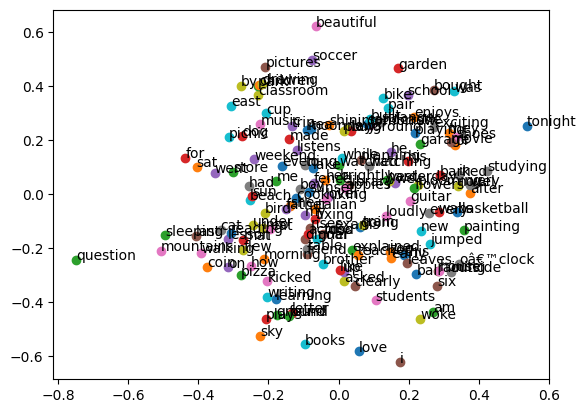

In [14]:
import matplotlib.pyplot as plt

for word in all_words:
    coordinates = word_embedding[word]
    plt.scatter(coordinates[0], coordinates[1])
    plt.annotate(word, [coordinates[0], coordinates[1]])

In [ ]:
#Future Work- Use Gensim library

In [ ]:
def predict_next_word(input_word, model, words_dict, all_words):
    if input_word not in words_dict:
        return "Error"
    
    x = np.zeros((1, len(all_words)))
    x[0][words_dict[input_word]] = 1
    
    prediction = model.predict(x, verbose=0)[0]
    predicted_index = np.argmax(prediction)
    
    return all_words[predicted_index]

ask = input("Type your word from the corpus list")
print("The next word is: ", predict_next_word(ask, model, words_dict, all_words))

The next word is:  reading
